## Customer Segmentation for Retail Banking Using K-Prototypes (Bank-Full Dataset)


(e.g., high balance but low campaign responsiveness; or frequent campaign contacts, or risk-relevant behavioral traits)

In [1]:
1. Problem Statement

Retail banks interact with diverse customers who differ in their financial profile, risk characteristics, and engagement behavior. 
However, most marketing campaigns and product recommendations are run uniformly, leading to:

--High campaign costs

--Low conversion rates

--Suboptimal targeting

--Missing high-value customer opportunities

--Unnecessary repeated calls to uninterested segments

SyntaxError: invalid syntax (550586746.py, line 1)

2. Goal
The goal is to segment bank customers into distinct, data-driven groups using demographic, financial, and behavioral features to support:

Cross-sell / up-sell strategies

Lending lead identification

Personalized marketing

Prioritization of customers based on potential and interest

In [ ]:
3. Dataset Used

45,211 customers

17 features (demographic + financial + campaign behavior)

Includes crucial financial fields like balance, loan flags, and campaign history

In [ ]:
3. Business Understanding
Banking Objective

Create meaningful customer segments that help answer:

1️⃣ Who are our high-potential lending customers?

High balance

Good repayment behavior

Lower loan exposure

2️⃣ Which segments respond well to marketing campaigns?

Customers with successful past campaigns

Easy-to-contact customers

3️⃣ Which customers are “hard to reach” or “low potential”?

Multiple failed contacts

Very low balance

Less interest in banking offers

These segments help optimize cross-selling of:

Personal loans

Home loans

Credit cards

Deposits and investment products

In [3]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
bank_full=pd.read_csv("bank-full.csv",sep=';')

In [5]:
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
bank_full.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [7]:
bank_full.shape

(45211, 17)

In [8]:
for i in bank_full.columns:
    print(bank_full[i].value_counts())

age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
93       2
90       2
95       2
88       2
94       1
Name: count, Length: 77, dtype: int64
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
balance
 0        3514
 1         195
 2         156
 4         139
 3         134
          ... 
-381         1
 4617        1
 20584       1
 4358        1
 16353       1
Name: count, Length: 7168, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no   

In [9]:
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## Data Cleaning and Feature Engineering
Cleaning & Type Conversion

Converted categorical variables to string

Converted yes/no flags for housing, loan, default into binary (1/0)

In [10]:
# Loan flags already present: housing, loan, default
# Convert yes/no to 1/0


flag_cols = ['housing', 'loan', 'default']
for col in flag_cols:
    bank_full[col] = bank_full[col].map({'yes': 1, 'no': 0})

## Balance Segmentation (important for lending & cross-sell)
Customers grouped into:

Negative balance

Low

Medium

High

This helps identify customers with high transactional value.

In [11]:
# Create balance buckets (very useful feature)
bins=[-5000,0,2000,10000,50000]
labels=['neg_balance','low','medium','high']
bank_full['balance_segment']=pd.cut(bank_full['balance'],bins=bins,labels=labels)

In [12]:
# Convert target variable to 1/0
bank_full['y']=bank_full['y'].map({'yes':1,'no':0})

## Campaign Behavior Features

campaign: engagement frequency

pdays: days since last contact

previous: prior campaign attempts

poutcome: success / failure

These features help understand responsiveness.

In [13]:
# 4. Prepare Categorical & Numerical Features
categorical_cols=['job','marital','education','contact','month','poutcome','balance_segment']
numerical_cols=['age','balance','duration','campaign','pdays','previous','housing','loan','default']

In [14]:
from sklearn.preprocessing import StandardScaler

## Scaling Numerical Features

Numerical variables were standardized for clustering stability.

In [15]:
#Scale numerical features
scaler=StandardScaler()
df_scaled=bank_full.copy()
df_scaled[numerical_cols]=scaler.fit_transform(bank_full[numerical_cols])

In [16]:
# Prepare matrix for K-Prototypes
X=df_scaled[categorical_cols+numerical_cols].copy()
X[categorical_cols]=X[categorical_cols].astype(str)

## Choice of Algorithm — Why K-Prototypes?

The dataset contains:

Mixed data (Numerical + Categorical)

Large customer volume (45k+)

Traditional algorithms have limitations:

Algorithm	Weakness
K-Means	Only numeric data
K-Modes	Only categorical
DBSCAN	Not suitable for high-dimensional mixed data
Hierarchical	Too slow for 45k samples

### K-Prototypes combines the strengths of K-Means + K-Modes and handles both types effectively.

In [17]:
##Run K-prototype
k=5
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))

In [18]:
bank_full['cluster']=clusters

In [19]:
bank_full.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_segment,cluster
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,0,medium,1
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,0,low,1
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,0,low,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,0,low,1
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,0,low,4


## Model Training
6.1 Feature Matrix Setup

All columns combined into a single matrix:

Categorical → string

Numerical → scaled

## Optimal Number of Clusters

Used cost-elbow method:

kproto.cost_


Evaluated K = 2 to 10 clusters.
Selected 5 clusters as the optimal point.

In [ ]:
cost=[]
for num_clusters in list(range(2,4)):
    kproto=KPrototypes(n_clusters=num_clusters,init='Huang',random_state=42)
    kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))
    cost.append(kproto.cost_)

plt.plot(cost)

## Training the K-Prototypes Model
kproto = KPrototypes(n_clusters=5, init='Huang', random_state=42)
clusters = kproto.fit_predict(X, categorical=cat_idx)


Added cluster labels to the dataset.

In [ ]:
k=4
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))
kproto.cost_

In [ ]:
##Run K-prototype
k=5
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))

In [ ]:
kproto.cost_

In [ ]:
k=6
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))
kproto.cost_

In [ ]:
k=7
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))
kproto.cost_

In [ ]:
k=8
kproto=KPrototypes(n_clusters=k,init='Huang',random_state=42)
clusters=kproto.fit_predict(X,categorical=list(range(len(categorical_cols))))
kproto.cost_

In [22]:
#6. Cluster Profiling
# --------------------------


cluster_profile = bank_full.groupby('cluster')[numerical_cols].mean()
cat_profile = bank_full.groupby('cluster')[categorical_cols].agg(lambda x: x.value_counts().index[0])

In [24]:
from sklearn.decomposition import PCA

In [25]:
# 7. PCA Visualization
pca=PCA(n_components=2)
X_num_pca=pca.fit_transform(df_scaled[numerical_cols])

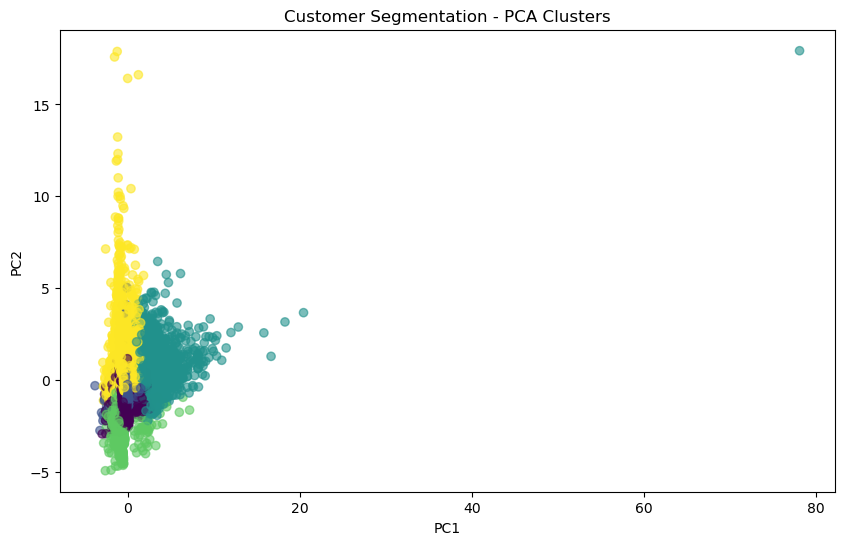

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(X_num_pca[:,0],X_num_pca[:,1],c=bank_full['cluster'],alpha=0.6)
plt.title("Customer Segmentation - PCA Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [29]:
bank_full.to_csv('segmented_customers.csv',index=False)
print("Saved : segmented_customers.csv")

Saved : segmented_customers.csv


## 7. Cluster Profiling & Interpretation

This is where banking domain expertise comes in.

Cluster 0 — High Balance / Low Loans / Hard to Reach

High financial potential

Not very responsive

Target for investment & high-ticket loans

Cluster 1 — Low Balance / Multi-Loans / High Engagement

Lower income

Already have loan exposure

Respond well to calls

Target for low-ticket cross-sell (credit card, small PL)

Cluster 2 — Medium Balance / Loan-free / Responsive

Good potential

Lower risk

Ideal for pre-approved offers

Cluster 3 — Young / Low balance / Easily Contactable

New-to-bank or young customers

Can be nurtured for long-term value

Cluster 4 — Previously contacted many times / No success

“Hard to convert” segment

Reduce campaign costs by excluding or re-strategizing